In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
!pip install geopandas cartopy shapely pyproj


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 103.1 MB/s eta 0:00:00


In [4]:
!pip install matplotlib-scalebar


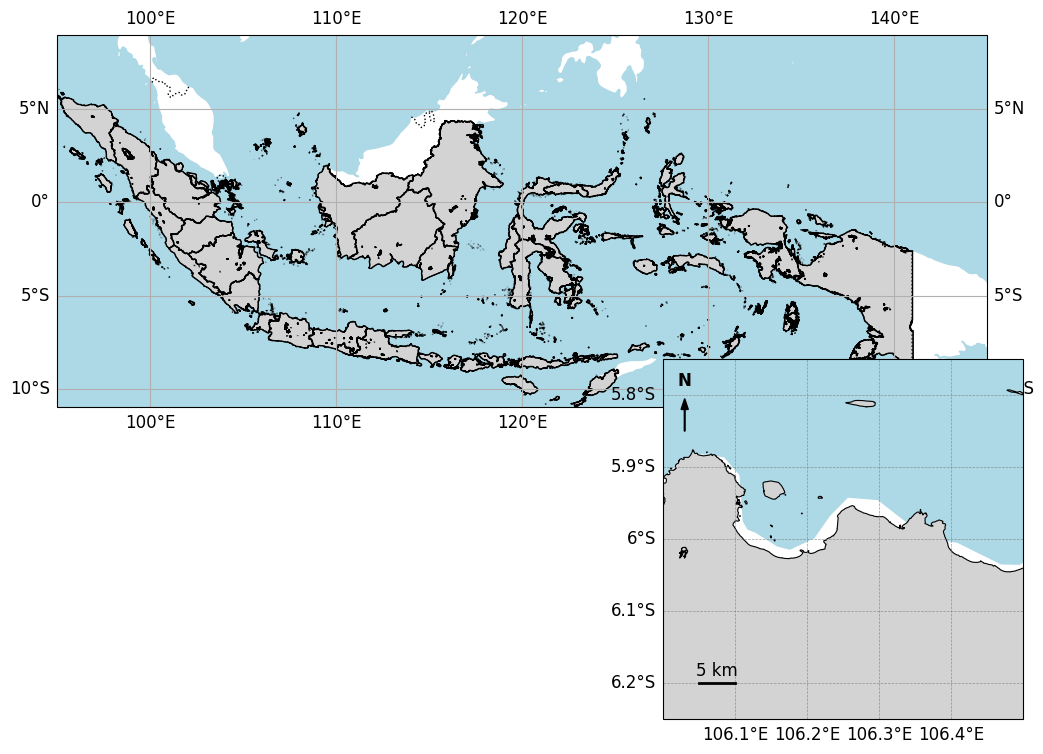

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from zipfile import ZipFile
import os
from matplotlib_scalebar.scalebar import ScaleBar
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker

# Unzip shapefile
zip_path = '/content/gdrive/My Drive/0 - FORECASTING/03 - ANN/provinsi.zip'
extract_dir = '/content/province_shp'

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Find .shp file
for file in os.listdir(extract_dir):
    if file.endswith('.shp'):
        shp_path = os.path.join(extract_dir, file)
        break

# Load shapefile
gdf = gpd.read_file(shp_path)

# Coordinate bounds
main_extent = [95, 145, -11, 9]
inset_extent = [106, 106.5, -6.25, -5.75]

# Main projection
proj = ccrs.PlateCarree()

# Create figure
fig = plt.figure(figsize=(12, 12))
main_ax = fig.add_subplot(1, 1, 1, projection=proj)
main_ax.set_extent(main_extent, crs=proj)

# Base map
main_ax.add_feature(cfeature.LAND, color='white')
main_ax.add_feature(cfeature.OCEAN, color='lightblue')
main_ax.add_feature(cfeature.BORDERS, linestyle=':')

# Custom gridlines: every 5° for latitude and every 10° for longitude
gl = main_ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.xlocator = mticker.FixedLocator(list(range(90, 151, 10)))     # Longitudes: 90E–150E, every 10°
gl.ylocator = mticker.FixedLocator(list(range(-10, 11, 5)))       # Latitudes: 10°S to 10°N, every 5°
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
gl.right_labels = True
gl.top_labels = True

# Overlay: Indonesian provinces in light gray
gdf.to_crs(epsg=4326).plot(ax=main_ax, edgecolor='black', facecolor='lightgray', linewidth=0.6)


# Plot shapefile
gdf.to_crs(epsg=4326).plot(ax=main_ax, edgecolor='black', facecolor='none', linewidth=1)

# Create inset axes manually
inset_ax = fig.add_axes([0.63, 0.08, 0.3, 0.3], projection=proj)
inset_ax.set_extent(inset_extent, crs=proj)

# Plot in inset
# Plot in inset
inset_ax.add_feature(cfeature.OCEAN, color='lightblue')
gl_inset = inset_ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.8, linestyle='--')
gl_inset.top_labels = False
gl_inset.right_labels = False
gl_inset.left_labels = True
gl_inset.bottom_labels = True
gl_inset.xlabel_style = {'size': 12}
gl_inset.ylabel_style = {'size': 12}

# Plot only your shapefile for coastlines
gdf.to_crs(epsg=4326).plot(ax=inset_ax, edgecolor='black', facecolor='lightgray', linewidth=0.8)

# Add north arrow
inset_ax.text(106.03, -5.78, 'N', fontsize=12, ha='center', va='center', fontweight='bold')
inset_ax.arrow(106.03, -5.85, 0, 0.03, head_width=0.01, head_length=0.015, fc='k', ec='k')

# Add scale bar manually
inset_ax.plot([106.05, 106.10], [-6.20, -6.20], color='black', lw=2)
inset_ax.text(106.075, -6.19, '5 km', ha='center', fontsize=12)

# Save to PDF
output_path = '/content/gdrive/My Drive/0 - FORECASTING/03 - ANN/indonesia_map_with_inset.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight')

plt.show()


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


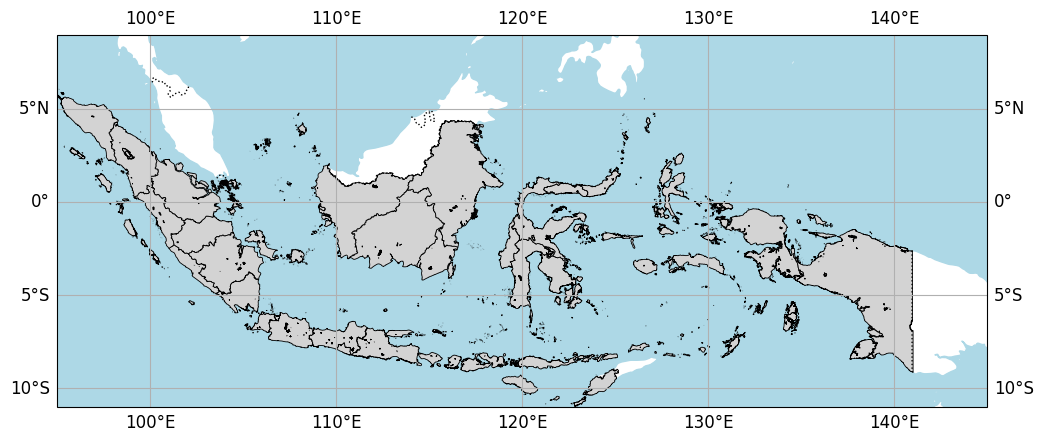

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from zipfile import ZipFile
import os
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker

# Unzip shapefile
zip_path = '/content/gdrive/My Drive/0 - FORECASTING/03 - ANN/provinsi.zip'
extract_dir = '/content/province_shp'

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Find .shp file
for file in os.listdir(extract_dir):
    if file.endswith('.shp'):
        shp_path = os.path.join(extract_dir, file)
        break

# Load shapefile
gdf = gpd.read_file(shp_path)

# Coordinate bounds
main_extent = [95, 145, -11, 9]

# Main projection
proj = ccrs.PlateCarree()

# Create figure
fig = plt.figure(figsize=(12, 12))
main_ax = fig.add_subplot(1, 1, 1, projection=proj)
main_ax.set_extent(main_extent, crs=proj)

# Base map
main_ax.add_feature(cfeature.LAND, color='white')
main_ax.add_feature(cfeature.OCEAN, color='lightblue')
main_ax.add_feature(cfeature.BORDERS, linestyle=':')

# Gridlines
gl = main_ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.xlocator = mticker.FixedLocator(list(range(90, 151, 10)))     # Longitudes: 90E–150E
gl.ylocator = mticker.FixedLocator(list(range(-10, 11, 5)))       # Latitudes: 10°S to 10°N
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
gl.right_labels = True
gl.top_labels = True

# Plot shapefile
gdf.to_crs(epsg=4326).plot(ax=main_ax, edgecolor='black', facecolor='lightgray', linewidth=0.6)

# Save to PDF
output_path = '/content/gdrive/My Drive/0 - FORECASTING/03 - ANN/indonesia_map_only.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight')

plt.show()
